# Spherical Harmonics Spectra Calcs 

### Written by: Will Chapman (wchapman@colorado.edu) or https://github.com/WillyChap                                                        
          
**Descripition**:

This notebook computes spherical harmonic power spectra from gridded atmospheric data, using the `torch_harmonics` library wrapped in a convenience class (`SpectralOpsTH`) plus some xarray helpers.  

The immediate goal is to take any scalar valued variable on a model grid, regrid them onto the spherical harmonic library grid, and then:

- transform into spectral space with a real spherical harmonic transform,
- construct total wavenumber spectra for scalar fields (e.g. `U`, `V`, or kinetic energy),
- optionally scale spectra so that their sum equals the global variance of the field,
- verify the normalization via Parseval checks against area-weighted grid integrals,
- and produce log–log spectra figures

This notebook is meant as both a testbed for the spectral formulation and a template for reusing the workflow with other fields, levels, and datasets.

### History

- V1. Dec 03 2025 – initial build and testing

---
### Some Details

Key ingredients and choices:

- **Data:** Gridded scalar product


- **Core libraries:**  
  - `xarray` for labeled multi-dimensional arrays  
  - `torch` and `torch_harmonics` for spherical harmonic transforms  
  - `xesmf` for conservative and bilinear regridding  
  - `numpy` and `matplotlib` for numerics and plotting  

- **Grid handling:**
  - Input latitude is forced to be ascending for consistency.
  - Fields are regridded to the spectral library grid (`legendre-gauss` or `lobatto` as configured in `SpectralOpsTH`).
  - Regridding is done once up front; all subsequent spectral operations are performed on the library grid.

- **Spectral operator (`SpectralOpsTH`):**
  - Wraps `torch_harmonics.RealSHT` / `InverseRealSHT` and vector SHTs.
  - Provides scalar transforms (`grid2spec`, `spec2grid`) and vector Helmholtz tools.
  - Exposes a `scalar_power_spectrum` method that builds total wavenumber spectra by summing `|f_{l m}|^2` over the m index for each total wavenumber `l`.

- **Xarray spectrum helper (`scalar_power_spectrum_xr`):**
  - Accepts an `xr.DataArray` with dims like `(time, lat, lon)` or `(member, time, lat, lon)`.
  - Stacks any chosen sample dims into a single `sample` dimension and averages spectra over all samples.
  - Handles optional interpolation to the library grid.
  - Optionally rescales spectra into **variance units** using the normalization specific to `RealSHT`:
    $
      \int_{S^2} f^2 \, d\Omega = 2 \sum_{l,m} |f_{lm}|^2
    $
    so that
    $
      \langle f^2 \rangle = \frac{1}{4\pi} \int_{S^2} f^2 d\Omega
                           = \frac{1}{2\pi} \sum_{l,m} |f_{lm}|^2.
    $
  - With `scale_to_variance=True`, the spectrum is scaled such that $(\sum_n P_n = \langle f^2 \rangle)$.

- **Parseval verification:**
  - The notebook builds Gauss / Gauss-Lobatto quadrature weights consistent with the SHT grid.
  - For a selected snapshot of (for example) `V`, it:
    - computes `sum_{l,m} |f_{lm}|^2` from the SHT,
    - computes the spherical integral of `f^2` from the grid using the quadrature weights,
    - verifies that they match under the `RealSHT` normalization, and
    - checks that the variance from the spectrum equals the area-weighted variance from the grid.

- **Plots:**
  - Produces 1D total wavenumber spectra for `U` and `V`, averaged over a chosen set of times.
  - Uses log–log axes to match the style of canonical kinetic energy and variance spectra figures.
  - Optionally annotates an “isotropic length scale” axis derived from:
    $
      L_{\text{iso}}(n) \approx \frac{2\pi a}{\sqrt{n(n+1)}}
    $
    where $(a)$ is Earth’s radius and $(n)$ is total wavenumber.

---

### This notebook is to test the formulation in this paper:

We are following the spherical harmonic and total wavenumber spectrum formulation used in the reference paper whose figure we are trying to reproduce.

> **TODO (Will):** Insert full citation and link here, for example  
> *Author(s), Year: Title, Journal, Volume, Pages, DOI*  

The implementation here is designed so that:

- the definition of the spectrum matches the paper’s “total wavenumber” spectrum, and  
- the integrated spectrum recovers the true global variance of the field, validated via Parseval’s theorem on the same grid and quadrature as the SHT.








In [ ]:
# === CONFIGURATION — edit paths here ===
SCHEDULER_DIR           = '/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler'
PRODUCTION_NETCDF_DIR   = '/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/production/sixteen_tune/netcdf'
BETA_DATA_DIR           = '/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/beta_data'
# Archive (read-only): all outputs are backed up to:
#   /glade/campaign/cisl/aiml/credit/models/sdl_camulator/era5_ensemble_2022


In [1]:
from __future__ import annotations

import argparse
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import xarray as xr
from scipy.sparse import coo_matrix, csc_matrix
from scipy.sparse.linalg import splu
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch_harmonics as th
import math
import xesmf as xe

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats as st


import glob
import numpy as np
from numpy.polynomial.legendre import Legendre, leggauss

EARTH_RADIUS = 6_371_000.0
EARTH_RADIUS = 6.371_000e6  # metres
EARTH_OMEGA = 7.292_115_9e-5  # radians / second
SEC_PER_DAY = 86_400.0

## Functions

In [2]:
def ensure_descending_lat(ds: xr.Dataset, lat_name: str = "lat") -> xr.Dataset:
    lat = ds[lat_name]
    if lat.ndim != 1:
        raise ValueError(f"Latitude coordinate {lat_name!r} must be one-dimensional.")
    if lat.values[0] < lat.values[-1]:
        return ds.sortby(lat_name, ascending=False)
    return ds

def ensure_ascending_lat(ds: xr.Dataset, lat_name: str = "lat") -> xr.Dataset:
    lat = ds[lat_name]
    if lat.ndim != 1:
        raise ValueError(f"{lat_name!r} must be one-dimensional.")
    if lat.values[0] > lat.values[-1]:
        return ds.sortby(lat_name, ascending=True)
    return ds
    
def infer_time_step_days(time: xr.DataArray) -> float:
    if time.ndim != 1 or time.size < 2:
        raise ValueError("Time coordinate must have at least two entries.")
    diffs = np.diff(time.values.astype("datetime64[s]").astype(np.int64))
    median_seconds = float(np.median(diffs))
    if not np.allclose(diffs, median_seconds, rtol=0.05):
        raise ValueError("Time steps are not constant to within 5%; daily sampling is required.")
    return median_seconds / SEC_PER_DAY


def fft_low_pass(da: xr.DataArray, cutoff_days: float, dt_days: float) -> xr.DataArray:
    """Return a low-pass filtered copy of *da* using a sharp FFT mask."""
    data = np.asarray(da.transpose("time", "lat", "lon").values, dtype=np.float64)
    nt = data.shape[0]
    freqs = np.fft.rfftfreq(nt, d=dt_days)
    mask = np.ones_like(freqs)
    cutoff_freq = 1.0 / cutoff_days
    mask[freqs > cutoff_freq] = 0.0

    transformed = np.fft.rfft(data, axis=0)
    filtered = np.fft.irfft(transformed * mask[:, None, None], n=nt, axis=0)

    return xr.DataArray(
        filtered,
        dims=("time", "lat", "lon"),
        coords={"time": da.time, "lat": da.lat, "lon": da.lon},
        attrs={**da.attrs, "filter": f"low-pass (cutoff={cutoff_days}d)"},
    )

def compute_daily_climatology(da: xr.DataArray, smooth_window: int = 0) -> xr.DataArray:
    """Compute day-of-year climatology with optional smoothing."""
    climatology = da.groupby("time.dayofyear").mean("time")
    if smooth_window and smooth_window > 1:
        data = uniform_filter1d(
            climatology.values,
            size=smooth_window,
            axis=0,
            mode="wrap",
            origin=0,
        )
        climatology = xr.DataArray(
            data,
            dims=climatology.dims,
            coords=climatology.coords,
            attrs=climatology.attrs,
        )
    return climatology


def subtract_daily_climatology(
    da: xr.DataArray,
    smooth_window: int = 0,
    return_climatology: bool = False,
) -> xr.DataArray | Tuple[xr.DataArray, xr.DataArray]:
    """Subtract the (optionally smoothed) day-of-year climatology from *da*."""
    if "time" not in da.dims:
        raise ValueError("DataArray must include a 'time' dimension to remove seasonal cycle.")
    climatology = compute_daily_climatology(da, smooth_window)
    anomalies = da.groupby("time.dayofyear") - climatology
    anomalies.attrs.update(da.attrs)
    anomalies.attrs["seasonal_cycle_removed"] = "dayofyear"
    if return_climatology:
        return anomalies, climatology
    return anomalies


# move this to the VERY TOP of your file if you keep it
from __future__ import annotations

import numpy as np
import xarray as xr
import torch
import torch_harmonics as th


def _compute_latlon_nodes(nlat: int, nlon: int, grid: str, device, dtype):
    grid = str(grid).lower()
    if grid in ("legendre-gauss", "gauss", "gl"):
        from numpy.polynomial.legendre import Legendre
        Pn = Legendre.basis(nlat)
        x = np.sort(Pn.roots())
    elif grid in ("lobatto", "gauss-lobatto", "glb"):
        from numpy.polynomial.legendre import Legendre
        P = Legendre.basis(nlat - 1)
        dP = P.deriv()
        xi = np.sort(dP.roots())
        x = np.concatenate(([-1.0], xi, [1.0]))
    else:
        raise ValueError(f"unknown grid '{grid}'")
    theta = np.arccos(np.clip(x, -1.0, 1.0))
    lat_deg = 90.0 - np.rad2deg(theta)
    lon_deg = np.linspace(0.0, 360.0, num=nlon, endpoint=False)
    lat_t = torch.tensor(lat_deg, dtype=dtype, device=device)
    lon_t = torch.tensor(lon_deg, dtype=dtype, device=device)
    return lat_t, lon_t


# move this to the VERY TOP of your file if you keep it
from __future__ import annotations

import numpy as np
import xarray as xr
import torch
import torch_harmonics as th


def _compute_latlon_nodes(nlat: int, nlon: int, grid: str, device, dtype):
    grid = str(grid).lower()
    if grid in ("legendre-gauss", "gauss", "gl"):
        from numpy.polynomial.legendre import Legendre
        Pn = Legendre.basis(nlat)
        x = np.sort(Pn.roots())
    elif grid in ("lobatto", "gauss-lobatto", "glb"):
        from numpy.polynomial.legendre import Legendre
        P = Legendre.basis(nlat - 1)
        dP = P.deriv()
        xi = np.sort(dP.roots())
        x = np.concatenate(([-1.0], xi, [1.0]))
    else:
        raise ValueError(f"unknown grid '{grid}'")
    theta = np.arccos(np.clip(x, -1.0, 1.0))
    lat_deg = 90.0 - np.rad2deg(theta)
    lon_deg = np.linspace(0.0, 360.0, num=nlon, endpoint=False)
    lat_t = torch.tensor(lat_deg, dtype=dtype, device=device)
    lon_t = torch.tensor(lon_deg, dtype=dtype, device=device)
    return lat_t, lon_t


class SpectralOpsTH:
    def __init__(self, nlat: int, nlon: int, *,
                 grid: str = "legendre-gauss",
                 lmax: int | None = None, mmax: int | None = None,
                 device: str = "cuda", dtype=torch.float64,
                 eps_default: float = 0.0):
        self.device = torch.device(device)
        self.dtype = dtype
        self.nlat, self.nlon = int(nlat), int(nlon)
        self.a = float(EARTH_RADIUS)
        self.eps_default = float(eps_default)
        self.grid_name = str(grid).lower()
        self._lap_eigs = None

        self._lat_nodes, self._lon_nodes = _compute_latlon_nodes(
            self.nlat, self.nlon, self.grid_name, self.device, self.dtype
        )

        self.sht  = th.RealSHT(self.nlat, self.nlon, lmax, mmax, self.grid_name, csphase=False).to(self.device, self.dtype)
        self.isht = th.InverseRealSHT(self.nlat, self.nlon, self.sht.lmax, self.sht.mmax, self.grid_name, csphase=False).to(self.device, self.dtype)
        self.vsht  = th.RealVectorSHT(self.nlat, self.nlon, self.sht.lmax, self.sht.mmax, self.grid_name, csphase=False).to(self.device, self.dtype)
        self.ivsht = th.InverseRealVectorSHT(self.nlat, self.nlon, self.sht.lmax, self.sht.mmax, self.grid_name, csphase=False).to(self.device, self.dtype)

        # L = torch.arange(0, self.sht.lmax, device=self.device, dtype=self.dtype).reshape(-1, 1)
        # L = L.expand(self.sht.lmax, self.sht.mmax)
        # self.lap_eigs = -(L * (L + 1)) / (self.a * self.a)

    # grid helpers
    def library_latlon(self):
        return self._lat_nodes, self._lon_nodes

    # scalar transforms
    def grid2spec(self, f: torch.Tensor) -> torch.Tensor:
        return self.sht(f.to(self.device, self.dtype))

    def spec2grid(self, sh: torch.Tensor) -> torch.Tensor:
        return self.isht(sh)

    # vector transforms
    def uv_to_psichi_spec(self, u: torch.Tensor, v: torch.Tensor):
        """
        Input: u (east), v (north) on the library grid.
        Output: (psi_hat_lib, chi_hat_lib) in the library's normalization.
        Do NOT apply radius factors here.
        """
        uv = torch.stack((u.to(self.device, self.dtype),
                          v.to(self.device, self.dtype)), dim=-3)
        psichi = self.vsht(uv)        # shape (..., 2, l, m)
        psi_hat_lib = psichi[..., 0, :, :]
        chi_hat_lib = psichi[..., 1, :, :]
        return psi_hat_lib, chi_hat_lib

    def psichi_spec_to_uv(self, psi_hat_lib: torch.Tensor, chi_hat_lib: torch.Tensor):
        """
        Inverse vector SHT using library-normalized potentials.
        """
        uv = self.ivsht(torch.stack((psi_hat_lib, chi_hat_lib), dim=-3))
        return uv.unbind(dim=-3)

    # Laplacian on scalar fields
    def laplacian(self, f: torch.Tensor) -> torch.Tensor:
        return self.spec2grid(self.lap_eigs * self.grid2spec(f))

    def _ensure_lap_eigs(self):
        """
        Build Laplacian eigenvalues with the exact (l,m) shape used by this SHT.
        Ensures: lap_eigs shape matches grid2spec(f).shape[-2:].
        """
        if self._lap_eigs is not None:
            return
        # Discover (l_dim, m_dim) from an actual scalar SHT output
        f0 = torch.zeros(self.nlat, self.nlon, dtype=self.dtype, device=self.device)
        fhat0 = self.grid2spec(f0)            # (..., l_dim, m_dim)
        l_dim, m_dim = int(fhat0.shape[-2]), int(fhat0.shape[-1])
        L = torch.arange(l_dim, dtype=self.dtype, device=self.device).reshape(-1, 1)
        L = L.expand(l_dim, m_dim)
        self._lap_eigs = -(L * (L + 1)) / (self.a * self.a)
    
    @property
    def lap_eigs(self):
        self._ensure_lap_eigs()
        return self._lap_eigs

    def inverse_laplacian(self, rhs: torch.Tensor, eps: float | None = None) -> torch.Tensor:
        eps = self.eps_default if eps is None else float(eps)
        rhs_hat = self.grid2spec(rhs)
        diag = self.lap_eigs - eps
        inv = torch.zeros_like(diag)
        inv[1:, :] = 1.0 / diag[1:, :]   # leave l=0 at 0 when eps==0
        psi_hat = rhs_hat * inv
        return self.spec2grid(psi_hat)
        
    # vorticity and divergence (grid)
    def relative_vorticity(self, u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        psi_hat_lib, _ = self.uv_to_psichi_spec(u, v)
        # FIX: multiply by a exactly once
        zeta_hat = self.a * self.lap_eigs * psi_hat_lib
        return self.spec2grid(zeta_hat)

    def divergence(self, u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        _, chi_hat_lib = self.uv_to_psichi_spec(u, v)
        # FIX: multiply by a exactly once
        div_hat = self.a * self.lap_eigs * chi_hat_lib
        return self.spec2grid(div_hat)

    # ---------- gradients (windspharm-style) ----------
    # ---------- gradients (windspharm-style) ----------
    def gradient_and_partials(self, f: torch.Tensor):
        """
        Compute both metric-weighted gradient and pure partials of a scalar f.
        Returns:
          (g_lam, g_phi): metric-weighted components with units of f per meter
              g_lam = (1/(a cos phi)) * df/dlambda   [eastward]
              g_phi = (1/a)            * df/dphi     [northward]
          (dlam, dphi): pure partial derivatives (per radian)
              dlam = df/dlambda
              dphi = df/dphi
        """
        # 1) Scalar SHT
        fhat = self.grid2spec(f)  # (..., l, m)
    
        # 2) Synthesize gradient via vector iSHT:
        #    use poloidal coefficient chi_hat = fhat / a, toroidal = 0
        zero = torch.zeros_like(fhat)
        g_lam, g_phi = self.psichi_spec_to_uv(zero, fhat / self.a)
    
        # 3) Convert to pure partials
        lat, _ = self.library_latlon()
        cosphi = torch.cos(torch.deg2rad(lat)).to(self.device, self.dtype)
        dlam = g_lam * (self.a * cosphi[:, None])  # df/dlambda
        dphi = g_phi * self.a                      # df/dphi
    
        # 4) Pole safety: g_lam must be 0 at the true poles
        pole = cosphi.abs() < 1e-12

        if g_lam.ndim == 2:
            # (lat, lon)
            g_lam[pole, :] = 0.0
            dlam[pole, :]  = 0.0
        else:
            # (..., lat, lon)
            sl_pole = (slice(None),) * (g_lam.ndim - 2) + (pole, slice(None))
            g_lam[sl_pole] = 0.0
            dlam[sl_pole]  = 0.0
    
        return (g_lam, g_phi), (dlam, dphi)
    
    def gradient(self, f: torch.Tensor):
        """
        Windspharm analog: returns metric-weighted gradient components (east, north)
        with units of f per meter.
        Usage: gx, gy = op.gradient(f)
        """
        (g_lam, g_phi), _ = self.gradient_and_partials(f)
        return g_lam, g_phi
    
    def derivative_lon(self, f: torch.Tensor) -> torch.Tensor:
        _, (dlam, _) = self.gradient_and_partials(f)
        return dlam
    
    def derivative_lat(self, f: torch.Tensor) -> torch.Tensor:
        _, (_, dphi) = self.gradient_and_partials(f)
        return dphi

    

    def helmholtz(self, u: torch.Tensor, v: torch.Tensor, eps: float | None = None):
        psi_hat_lib, chi_hat_lib = self.uv_to_psichi_spec(u, v)
    
        # library-normalized scalar fields
        psi_lib = self.spec2grid(psi_hat_lib)
        chi_lib = self.spec2grid(chi_hat_lib)
    
        # physical winds (same as before)
        u_rot, v_rot = self.psichi_spec_to_uv(psi_hat_lib, torch.zeros_like(chi_hat_lib))
        u_div, v_div = self.psichi_spec_to_uv(torch.zeros_like(psi_hat_lib), chi_hat_lib)
    
        # physical diagnostics
        zeta = self.spec2grid(self.a * self.lap_eigs * psi_hat_lib)   # 1/s
        div  = self.spec2grid(self.a * self.lap_eigs * chi_hat_lib)   # 1/s
    
        # physical potentials (m^2/s)
        psi_phys = self.a * psi_lib
        chi_phys = self.a * chi_lib
    
        return {
            "psi_lib": psi_lib, "chi_lib": chi_lib,
            "psi": psi_phys,    "chi": chi_phys,
            "u_rot": u_rot, "v_rot": v_rot,
            "u_div": u_div, "v_div": v_div,
            "zeta": zeta, "div": div,
        }

    def scalar_power_spectrum(self, f: torch.Tensor) -> torch.Tensor:
        """
        Total wavenumber spectrum of a scalar field.

        Parameters
        ----------
        f : torch.Tensor
            Field on the library grid with shape (..., nlat, nlon).

        Returns
        -------
        spec_l : torch.Tensor
            1D tensor of length l_dim giving the power at each total
            wavenumber l (a.k.a. n).
            Sum over m has already been done.
        """
        f_hat = self.grid2spec(f)  # (..., l, m)

        # handle real vs complex coefficients
        if torch.is_complex(f_hat):
            power_lm = f_hat.real**2 + f_hat.imag**2
        else:
            power_lm = f_hat**2

        # sum over "m" dimension (last one)
        spec_l = power_lm.sum(dim=-1)        # (..., l)

        # if there are extra leading dims, average them
        if spec_l.ndim > 1:
            lead = int(torch.prod(torch.tensor(spec_l.shape[:-1])))
            spec_l = spec_l.reshape(lead, spec_l.shape[-1]).mean(dim=0)

        return spec_l  # (l_dim,)

def helmholtz_decompose_spectral_xr(
    u_da: xr.DataArray,
    v_da: xr.DataArray,
    ops,                                # SpectralOpsTH instance (already constructed)
    *,
    eps: float | None = None,           # if ops.helmholtz uses eps; otherwise ignored
    batch_size: int = 16,               # number of time steps per spectral call
    device: str | None = None,          # override device (e.g., "cuda"); defaults to ops.device
    remap_to_library_grid: bool = True, # if True, interp to ops.library_latlon() when needed
    show_progress=True,
) -> xr.Dataset:
    """
    Spectral (torch-harmonics) Helmholtz decomposition over (time, lat, lon) arrays.

    Returns an xr.Dataset with variables:
      psi, chi, u_rot, v_rot, u_div, v_div, zeta, div
    Coordinates will be on the library grid if remapping occurred; otherwise original.
    """
    # ---- 0) basic checks ----
    if u_da.dims != v_da.dims:
        raise ValueError("u_da and v_da must share the exact dims (time, lat, lon).")
    if tuple(u_da.dims)[-2:] != ("lat", "lon"):
        raise ValueError("Last two dims must be ('lat','lon').")
    if "time" not in u_da.dims:
        raise ValueError("Expect a 'time' dimension.")
    if not np.array_equal(u_da.time.values, v_da.time.values):
        raise ValueError("Time coordinates differ between u and v.")
    if not np.array_equal(u_da.lat.values, v_da.lat.values) or not np.array_equal(u_da.lon.values, v_da.lon.values):
        raise ValueError("Lat/Lon coordinates differ between u and v.")

    # ---- 1) ensure the grid matches the library grid (if requested) ----
    lat_src = u_da.lat.values
    lon_src = u_da.lon.values
    lat_lib, lon_lib = ops.library_latlon()  # torch tensors (deg)
    lat_lib_np = np.asarray(lat_lib.cpu().numpy())
    lon_lib_np = np.asarray(lon_lib.cpu().numpy())

    lat_ok = np.allclose(lat_src, lat_lib_np, atol=1e-10)
    lon_ok = np.allclose(lon_src, lon_lib_np, atol=1e-10)

    if remap_to_library_grid and (not lat_ok or not lon_ok):
        # conservative would be nicer, but linear interp is usually fine for winds
        u_in = u_da.interp(lat=lat_lib_np, lon=lon_lib_np, kwargs={"fill_value": "extrapolate"})
        v_in = v_da.interp(lat=lat_lib_np, lon=lon_lib_np, kwargs={"fill_value": "extrapolate"})
        lat_out = lat_lib_np
        lon_out = lon_lib_np
    else:
        u_in, v_in = u_da, v_da
        lat_out = u_in.lat.values
        lon_out = u_in.lon.values

    # ---- 2) torch setup ----
    dev = torch.device(device) if device is not None else ops.device
    dtype = torch.float64  # use float64 for spectral accuracy

    nt = u_in.sizes["time"]
    nlat = u_in.sizes["lat"]
    nlon = u_in.sizes["lon"]

    # containers
    out_psi   = []
    out_chi   = []
    out_u_rot = []
    out_v_rot = []
    out_u_div = []
    out_v_div = []
    out_zeta  = []
    out_div   = []

    # ---- 3) loop over time in batches ----
    steps = range(0, nt, batch_size)
    if show_progress:
        try:
            from tqdm.auto import tqdm
            steps = tqdm(steps, total=math.ceil(nt / batch_size),
                         desc="Spectral Helmholtz", leave=False)
        except Exception:
            pass
            
    for t0 in steps:
        t1 = min(nt, t0 + batch_size)

        u_blk = torch.from_numpy(u_in.isel(time=slice(t0, t1)).values).to(dtype=dtype, device=dev)  # (B, nlat, nlon)
        v_blk = torch.from_numpy(v_in.isel(time=slice(t0, t1)).values).to(dtype=dtype, device=dev)

        # ops.helmholtz supports batch leading dims → just pass (B, nlat, nlon)
        res = ops.helmholtz(u_blk, v_blk, eps=eps)

        # detach → numpy
        to_np = lambda x: x.detach().to("cpu").numpy()
        out_psi.append(  to_np(res["psi"]) )
        out_chi.append(  to_np(res["chi"]) )
        out_u_rot.append(to_np(res["u_rot"]))
        out_v_rot.append(to_np(res["v_rot"]))
        out_u_div.append(to_np(res["u_div"]))
        out_v_div.append(to_np(res["v_div"]))
        out_zeta.append( to_np(res["zeta"]) )
        out_div.append(  to_np(res["div"]) )

        # free GPU memory incrementally (if on cuda)
        del u_blk, v_blk, res
        if dev.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

    # ---- 4) stitch batches and build Dataset ----
    cat = lambda lst: np.concatenate(lst, axis=0) if (nt > 0) else np.zeros((0, nlat, nlon))
    psi   = cat(out_psi)
    chi   = cat(out_chi)
    u_rot = cat(out_u_rot)
    v_rot = cat(out_v_rot)
    u_div = cat(out_u_div)
    v_div = cat(out_v_div)
    zeta  = cat(out_zeta)
    divg  = cat(out_div)

    coords = {"time": u_in.time.values, "lat": lat_out, "lon": lon_out}
    ds = xr.Dataset(
        data_vars=dict(
            psi   =(("time","lat","lon"), psi),
            chi   =(("time","lat","lon"), chi),
            u_rot =(("time","lat","lon"), u_rot),
            v_rot =(("time","lat","lon"), v_rot),
            u_div =(("time","lat","lon"), u_div),
            v_div =(("time","lat","lon"), v_div),
            zeta  =(("time","lat","lon"), zeta),
            div   =(("time","lat","lon"), divg),
        ),
        coords=coords,
        attrs=dict(method="torch-harmonics spectral Helmholtz", grid=str(getattr(ops, "grid_name", "library")))
    )

    # optional quick closure metrics as attrs
    # (compare on library grid if a remap happened)
    u_rec = u_rot + u_div
    v_rec = v_rot + v_div
    def rel_rms(a, b):
        num = float(np.sqrt(np.mean((a-b)**2)))
        den = float(np.sqrt(np.mean(b**2)) + 1e-30)
        return num/den
    ds.attrs["closure_rel_rms_u"] = rel_rms(u_rec, u_in.values)
    ds.attrs["closure_rel_rms_v"] = rel_rms(v_rec, v_in.values)
    ds.attrs["remapped_to_library_grid"] = bool(remap_to_library_grid and (not lat_ok or not lon_ok))
    return ds


def gradient_xr(da_or_ds, ops, var=None, *, remap_to_library_grid=True, batch_size=16, device=None):
    import numpy as np, xarray as xr, torch

    # 0) pick DataArray
    if isinstance(da_or_ds, xr.Dataset):
        if var is None:
            raise ValueError("When passing a Dataset, specify var='<variable_name>'")
        da = da_or_ds[var]
        base = f"grad_{var}"
    else:
        da = da_or_ds
        base = "grad"

    # 1) checks / add time if missing
    if ("lat","lon") != da.dims[-2:]:
        raise ValueError("Last two dims must be ('lat','lon').")
    need_time = ("time" not in da.dims)
    if need_time:
        da = da.expand_dims(time=[0])

    # 2) remap to library grid if needed
    lat_lib_t, lon_lib_t = ops.library_latlon()
    lat_lib = np.asarray(lat_lib_t.cpu().numpy())
    lon_lib = np.asarray(lon_lib_t.cpu().numpy())

    same_lat = np.allclose(da.lat.values, lat_lib, atol=1e-10)
    same_lon = np.allclose(da.lon.values, lon_lib, atol=1e-10)

    if remap_to_library_grid and (not same_lat or not same_lon):
        da_in = da.interp(lat=lat_lib, lon=lon_lib, kwargs={"fill_value": "extrapolate"})
        lat_out, lon_out = lat_lib, lon_lib
    else:
        da_in = da
        lat_out, lon_out = da.lat.values, da.lon.values

    # 3) torch setup
    dev = torch.device(device) if device is not None else ops.device
    dtype = torch.float64
    nt = da_in.sizes["time"]

    # 4) batch
    out_gx = []
    out_gy = []
    for t0 in range(0, nt, batch_size):
        t1 = min(nt, t0 + batch_size)
        blk = torch.from_numpy(da_in.isel(time=slice(t0, t1)).values).to(dtype=dtype, device=dev)  # (B, nlat, nlon)
        # process per slice (safe)
        gx_list, gy_list = [], []
        for b in range(blk.shape[0]):
            gx_b, gy_b = ops.gradient(blk[b])  # returns metric-weighted components
            gx_list.append(gx_b.detach().to("cpu").numpy())
            gy_list.append(gy_b.detach().to("cpu").numpy())
        out_gx.append(np.stack(gx_list, axis=0))
        out_gy.append(np.stack(gy_list, axis=0))

    grad_x = np.concatenate(out_gx, axis=0)
    grad_y = np.concatenate(out_gy, axis=0)

    ds_out = xr.Dataset(
        data_vars={
            f"{base}_x": (("time","lat","lon"), grad_x),
            f"{base}_y": (("time","lat","lon"), grad_y),
        },
        coords={"time": da_in.time.values, "lat": lat_out, "lon": lon_out},
        attrs={"units": "per meter of input units", "note": "metric-weighted gradient"},
    )
    if need_time:
        ds_out = ds_out.isel(time=0, drop=True)
    return ds_out

def divergence_xr(u_da: xr.DataArray, v_da: xr.DataArray, ops,
                  *, remap_to_library_grid=True, batch_size=16, device=None, name="div"):
    # 0) basic checks
    if u_da.dims != v_da.dims:
        raise ValueError("u_da and v_da must share dims in the same order.")
    # accept either ('lat','lon') or ('latitude','longitude')
    lat_name = "lat" if "lat" in u_da.dims else "latitude"
    lon_name = "lon" if "lon" in u_da.dims else "longitude"
    if (lat_name, lon_name) != u_da.dims[-2:]:
        raise ValueError("Last two dims must be (lat, lon) or (latitude, longitude).")
    if not np.array_equal(u_da[lat_name], v_da[lat_name]) or not np.array_equal(u_da[lon_name], v_da[lon_name]):
        raise ValueError("Lat/Lon coordinates differ between u and v.")

    # 1) remap to library grid if requested
    lat_lib_t, lon_lib_t = ops.library_latlon()
    lat_lib = np.asarray(lat_lib_t.cpu().numpy())
    lon_lib = np.asarray(lon_lib_t.cpu().numpy())

    same_lat = np.allclose(u_da[lat_name].values, lat_lib, atol=1e-10)
    same_lon = np.allclose(u_da[lon_name].values, lon_lib, atol=1e-10)

    if remap_to_library_grid and (not same_lat or not same_lon):
        u_in = u_da.interp({lat_name: lat_lib, lon_name: lon_lib}, kwargs={"fill_value": "extrapolate"})
        v_in = v_da.interp({lat_name: lat_lib, lon_name: lon_lib}, kwargs={"fill_value": "extrapolate"})
        lat_out, lon_out = lat_lib, lon_lib
    else:
        u_in, v_in = u_da, v_da
        lat_out, lon_out = u_in[lat_name].values, u_in[lon_name].values

    # 2) ensure a time dim exists
    need_time = ("time" not in u_in.dims)
    if need_time:
        u_in = u_in.expand_dims(time=[0])
        v_in = v_in.expand_dims(time=[0])

    # 3) torch + batching
    dev = torch.device(device) if device is not None else ops.device
    dtype = torch.float64
    nt = u_in.sizes["time"]
    out = []

    for t0 in range(0, nt, batch_size):
        t1 = min(nt, t0 + batch_size)
        u_blk = torch.from_numpy(u_in.isel(time=slice(t0, t1)).values).to(dtype=dtype, device=dev)  # (B, nlat, nlon)
        v_blk = torch.from_numpy(v_in.isel(time=slice(t0, t1)).values).to(dtype=dtype, device=dev)
        # compute per-slice (safer on memory)
        div_list = []
        for b in range(u_blk.shape[0]):
            div_b = ops.divergence(u_blk[b], v_blk[b])  # [1/s], on library grid
            div_list.append(div_b.detach().to("cpu").numpy())
        out.append(np.stack(div_list, axis=0))
        del u_blk, v_blk, div_list

    div_all = np.concatenate(out, axis=0)  # (time, lat, lon)
    da_out = xr.DataArray(
        div_all if not need_time else div_all[0],  # drop synthetic time if added
        dims=("time", lat_name, lon_name) if not need_time else (lat_name, lon_name),
        coords=({"time": u_in.time.values, lat_name: lat_out, lon_name: lon_out} if not need_time
                else {lat_name: lat_out, lon_name: lon_out}),
        name=name,
        attrs={"units": "s^-1", "method": "torch-harmonics divergence"}
    )
    return da_out


def inverse_laplacian_xr(da: xr.DataArray, ops, *, eps=0.0,
                         remap_to_library_grid=True, batch_size=16, device=None, name=None, show_progress=True,):
    """
    Solve (nabla^2 - eps) psi = rhs for each time slice in `da` using SpectralOpsTH.
    - da: DataArray with dims (..., time?, lat, lon) where the last 2 are lat/lon.
    - eps=0.0 uses zero-mean gauge (l=0 set to 0).
    - Returns a DataArray on the library grid if remapping was necessary.
    """
    # normalize dims: ensure lat/lon names and put time dim in if missing
    lat_name = "lat" if "lat" in da.dims else ("latitude" if "latitude" in da.dims else None)
    lon_name = "lon" if "lon" in da.dims else ("longitude" if "longitude" in da.dims else None)
    if lat_name is None or lon_name is None or (lat_name, lon_name) != da.dims[-2:]:
        raise ValueError("Last two dims must be (lat, lon) or (latitude, longitude).")
    need_time = ("time" not in da.dims)
    if need_time:
        da = da.expand_dims(time=[0])

    # optional remap to the library grid
    lat_lib_t, lon_lib_t = ops.library_latlon()
    lat_lib = np.asarray(lat_lib_t.cpu().numpy())
    lon_lib = np.asarray(lon_lib_t.cpu().numpy())

    same_lat = np.allclose(da[lat_name].values, lat_lib, atol=1e-10)
    same_lon = np.allclose(da[lon_name].values, lon_lib, atol=1e-10)

    if remap_to_library_grid and (not same_lat or not same_lon):
        da_in = da.interp({lat_name: lat_lib, lon_name: lon_lib}, kwargs={"fill_value": "extrapolate"})
        lat_out, lon_out = lat_lib, lon_lib
    else:
        da_in = da
        lat_out, lon_out = da[lat_name].values, da[lon_name].values

    # torch setup
    dev = torch.device(device) if device is not None else ops.device
    dtype = torch.float64
    nt = da_in.sizes["time"]
    out = []

    # loop in batches

     # ---- 3) loop over time in batches ----
    steps = range(0, nt, batch_size)
    if show_progress:
        try:
            from tqdm.auto import tqdm
            steps = tqdm(steps, total=math.ceil(nt / batch_size),
                         desc="Spectral Helmholtz", leave=False)
        except Exception:
            pass
            
    for t0 in steps:
        t1 = min(nt, t0 + batch_size)
        blk = torch.from_numpy(da_in.isel(time=slice(t0, t1)).values).to(dtype=dtype, device=dev)  # (B, nlat, nlon)

        psi_list = []
        for b in range(blk.shape[0]):
            rhs = blk[b]
            # optional: enforce zero area-weighted mean if eps==0 (not strictly required since l=0 is zeroed)
            # lat weights:
            # w = torch.cos(torch.deg2rad(ops.library_latlon()[0]).to(dev, dtype))[:, None]
            # rhs = rhs - (rhs * w).sum() / w.sum()

            psi_b = ops.inverse_laplacian(rhs, eps=eps)  # physical psi (m^2/s for rhs in s^-1)
            psi_list.append(psi_b.detach().to("cpu").numpy())
        out.append(np.stack(psi_list, axis=0))

    psi = np.concatenate(out, axis=0)  # (time, lat, lon)

    da_out = xr.DataArray(
        psi if not need_time else psi[0],
        dims=("time", lat_name, lon_name) if not need_time else (lat_name, lon_name),
        coords=({"time": da_in.time.values, lat_name: lat_out, lon_name: lon_out} if not need_time
                else {lat_name: lat_out, lon_name: lon_out}),
        name=(name or f"{getattr(da, 'name', 'psi')}_ilap"),
        attrs={"units": "m^2 s^-1", "method": "spectral inverse Laplacian", "eps": float(eps)}
    )
    return da_out

def scalar_power_spectrum_xr(
    da: xr.DataArray,
    ops,
    *,
    sample_dims=("time",),
    remap_to_library_grid=True,
    batch_size=16,
    device=None,
    name="power",
    scale_to_variance=False,
    show_progress=True,
) -> xr.Dataset:
    """
    Total-wavenumber spherical harmonic spectrum of a scalar field.

    Parameters
    ----------
    da : xr.DataArray
        Scalar field with dims including lat/lon and one or more sample dims
        (e.g. time, member). All listed sample_dims will be averaged.
    ops : SpectralOpsTH
        Spectral operator with torch-harmonics SHT attached.
    sample_dims : tuple of str
        Dimensions over which to average the spectrum (e.g. ("time",)).
    remap_to_library_grid : bool
        If True, remap to ops.library_latlon() before transforms.
    batch_size : int
        Number of samples per torch batch.
    device : str or None
        Torch device override (e.g. "cuda"). Defaults to ops.device.
    name : str
        Name of the output spectrum variable.
    scale_to_variance : bool
        If False: spectrum is in raw SHT units, P_n = sum_m |f_lm|^2 (sample-mean).
        If True: spectrum is scaled so that sum_n P_n = global variance
        <f^2>, using RealSHT normalization int f^2 dOmega = 2 * sum_lm |f_lm|^2,
        so P_n = (1 / (2*pi)) * sum_m |f_lm|^2.
    show_progress : bool
        If True, show a tqdm progress bar if available.

    Returns
    -------
    xr.Dataset with coords:
        n          : total wavenumber
        L_iso_km   : isotropic length scale (km)
    and data var:
        name       : spectrum(n)
    """
    # lat/lon dim names
    lat_name = "lat" if "lat" in da.dims else "latitude"
    lon_name = "lon" if "lon" in da.dims else "longitude"
    if (lat_name, lon_name) != da.dims[-2:]:
        raise ValueError("Last two dims must be (lat, lon) or (latitude, longitude).")

    # 1) stack sample dims and move them to the front: (sample, lat, lon)
    sample_dims = tuple(d for d in sample_dims if d in da.dims)
    if len(sample_dims) == 0:
        da_sample = da.expand_dims(sample=[0]).transpose("sample", lat_name, lon_name)
    else:
        da_sample = (
            da
            .stack(sample=sample_dims)
            .transpose("sample", lat_name, lon_name)
        )

    # 2) remap to library grid if needed
    lat_lib_t, lon_lib_t = ops.library_latlon()
    lat_lib = np.asarray(lat_lib_t.cpu().numpy())
    lon_lib = np.asarray(lon_lib_t.cpu().numpy())

    same_lat = np.allclose(da_sample[lat_name].values, lat_lib, atol=1e-10)
    same_lon = np.allclose(da_sample[lon_name].values, lon_lib, atol=1e-10)

    if remap_to_library_grid and (not same_lat or not same_lon):
        da_in = da_sample.interp(
            {lat_name: lat_lib, lon_name: lon_lib},
            kwargs={"fill_value": "extrapolate"},
        )
    else:
        da_in = da_sample

    n_sample = da_in.sizes["sample"]
    dev = torch.device(device) if device is not None else ops.device
    dtype = torch.float64

    spec_sum = None
    count = 0

    steps = range(0, n_sample, batch_size)
    if show_progress:
        try:
            from tqdm.auto import tqdm
            steps = tqdm(
                steps,
                total=math.ceil(n_sample / batch_size),
                desc="Scalar spectrum",
                leave=False,
            )
        except Exception:
            pass

    # 3) loop over samples in batches
    for i0 in steps:
        i1 = min(n_sample, i0 + batch_size)

        # values.shape -> (B, nlat, nlon)
        blk = torch.from_numpy(
            da_in.isel(sample=slice(i0, i1)).values
        ).to(dtype=dtype, device=dev)

        for b in range(blk.shape[0]):
            f = blk[b]  # (nlat, nlon)
            spec_l = ops.scalar_power_spectrum(f)  # raw sum_m |f_lm|^2
            if spec_sum is None:
                spec_sum = torch.zeros_like(spec_l)
            spec_sum += spec_l
            count += 1

        del blk
        if dev.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

    if count == 0:
        raise ValueError("No samples found to average over.")

    # 4) average over samples
    spec_mean = (spec_sum / count).detach().to("cpu").numpy()

    # 5) optional scaling to variance units
    # RealSHT: int f^2 dOmega = 2 * sum_lm |f_lm|^2
    # global variance <f^2> = (1 / (4*pi)) * int f^2 dOmega
    #                       = sum_lm |f_lm|^2 / (2*pi)
    # so variance spectrum per n: P_n = (1 / (2*pi)) * sum_m |f_lm|^2
    if scale_to_variance:
        spec_mean = spec_mean / (2.0 * np.pi)

    l_dim = spec_mean.shape[0]
    n = np.arange(l_dim, dtype=int)

    # isotropic length scale (km), n=0 undefined
    a = EARTH_RADIUS
    length_scale = np.empty_like(spec_mean, dtype=float)
    length_scale[0] = np.nan
    nn = n[1:].astype(float)
    length_scale[1:] = 2 * np.pi * a / np.sqrt(nn * (nn + 1.0))
    length_scale_km = length_scale / 1000.0

    ds = xr.Dataset(
        data_vars={name: (("n",), spec_mean)},
        coords={
            "n": n,
            "L_iso_km": (("n",), length_scale_km),
        },
        attrs={
            "field_name": getattr(da, "name", ""),
            "note": "total-wavenumber spherical harmonic power spectrum",
            "n_samples": int(count),
            "scale_to_variance": bool(scale_to_variance),
            "normalization": (
                "RealSHT: int f^2 dOmega = 2 * sum_lm |f_lm|^2; "
                "if scale_to_variance=True, spectrum(n) sums to global variance <f^2>."
            ),
        },
    )
    return ds

def maybe_zero_polar_lon_grads(da: xr.DataArray) -> xr.DataArray:
    if not config.zero_polar_lon_grads:
        return da
    mask = np.abs(da.lat) < config.polar_lon_grad_lat
    return da.where(mask, 0.0)


def gauss_lobatto_nodes_weights(n):
    P = Legendre.basis(n - 1)
    dP = P.deriv()
    xi = np.sort(dP.roots())
    x = np.concatenate(([-1.0], xi, [1.0]))

    w = np.empty_like(x)
    w[0] = 2.0 / (n * (n - 1))
    w[-1] = w[0]
    Pn1_xi = P(x[1:-1])
    w[1:-1] = 2.0 / (n * (n - 1) * (Pn1_xi**2))
    return x, w

def lat_nodes_weights(nlat, grid="lobatto"):
    grid = str(grid).lower()
    if grid in ("legendre-gauss", "gauss", "gl"):
        x, w = leggauss(nlat)
    elif grid in ("lobatto", "gauss-lobatto", "glb"):
        x, w = gauss_lobatto_nodes_weights(nlat)
    else:
        raise ValueError(f"Unknown grid {grid!r}")
    return x, w

def check_parseval_v(v_da, ops, time_index=0):
    """
    Compare grid variance of var with spectral variance using RealSHT
    normalization (factor of 2).
    """
    field = v_da.isel(time=time_index).values      # (nlat, nlon)
    nlat, nlon = field.shape

    # spectral side
    f = torch.from_numpy(field).to(ops.device, ops.dtype)
    f_hat = ops.grid2spec(f)                       # (l, m)
    if torch.is_complex(f_hat):
        power_lm = f_hat.real**2 + f_hat.imag**2
    else:
        power_lm = f_hat**2

    spec_total = float(power_lm.sum().detach().cpu().numpy())  # sum_lm |f_lm|^2

    # grid side
    x, w_lat = lat_nodes_weights(nlat, grid=ops.grid_name)
    w_lat = np.asarray(w_lat)

    lat_lib, _ = ops.library_latlon()
    theta = np.deg2rad(90.0 - lat_lib.cpu().numpy())
    x_from_lat = np.cos(theta)
    print("max |node mismatch| =", np.max(np.abs(x - x_from_lat)))

    dlon = 2.0 * np.pi / float(nlon)
    f2 = field**2
    int_grid = float((f2 * w_lat[:, None]).sum() * dlon)

    # variances:
    # RealSHT normalization: ∫ f^2 dOMEGA = 2 * sum_lm |f_lm|^2
    var_spec = (2.0 * spec_total) / (4.0 * np.pi)   # = spec_total / (2pi)
    var_grid = int_grid / (4.0 * np.pi)

    rel_diff = abs(var_spec - var_grid) / var_grid

    print("spec_total =", spec_total)
    print("int_grid   =", int_grid)
    print("var_spec (from spectrum) =", var_spec)
    print("var_grid (area-weighted) =", var_grid)
    print("relative diff (Parseval) =", rel_diff)

    return dict(
        spec_total=spec_total,
        int_grid=int_grid,
        var_spec=var_spec,
        var_grid=var_grid,
        rel_diff=rel_diff,
    )


## Load Data and Run Model

In [3]:
# # -------------------------------------------------------------------
# # Paths and variable names
# # -------------------------------------------------------------------
# u_file = "/glade/campaign/cgd/amp/wchapman/Reanalysis/ERA5_uvz_msl_f09/era5_f09_U_1979_1985_300hPa.nc"
# v_file = "/glade/campaign/cgd/amp/wchapman/Reanalysis/ERA5_uvz_msl_f09/era5_f09_V_1979_1985_300hPa.nc"
# u_var  = "U"
# v_var  = "V"

# # Optional xarray chunking along time
# time_chunk = None  # e.g. 30 for chunks={"time": 30}
# chunks = {"time": time_chunk} if time_chunk else None

# # -------------------------------------------------------------------
# # Load data and ensure lat is ascending
# # -------------------------------------------------------------------
# u_ds = xr.open_dataset(u_file, chunks=chunks)
# v_ds = xr.open_dataset(v_file, chunks=chunks)

# u_ds = ensure_ascending_lat(u_ds)
# v_ds = ensure_ascending_lat(v_ds)

# u_da = u_ds[u_var].transpose("time", "lat", "lon").load()
# v_da = v_ds[v_var].transpose("time", "lat", "lon").load()

# # Basic consistency checks
# if u_da.dims != v_da.dims:
#     raise ValueError("U and V arrays must share dims (time, lat, lon).")
# if not np.allclose(u_da.lon, v_da.lon):
#     raise ValueError("Longitude coordinates do not match.")
# if not np.allclose(u_da.lat, v_da.lat):
#     raise ValueError("Latitude coordinates do not match.")
# if not np.all(u_da.time.values == v_da.time.values):
#     raise ValueError("Time coordinates do not match.")

# print("Input dims:", u_da.shape)

# # -------------------------------------------------------------------
# # Build spectral ops and regrid U,V to the library grid
# # -------------------------------------------------------------------
# ops = SpectralOpsTH(
#     nlat=u_da.sizes["lat"],
#     nlon=u_da.sizes["lon"],
#     grid="lobatto",
#     device="cpu",
#     eps_default=1e-12,
# )

# lat_lib, lon_lib = ops.library_latlon()
# target_grid = xr.Dataset(
#     dict(
#         lat=(["lat"], lat_lib.cpu().numpy()),
#         lon=(["lon"], lon_lib.cpu().numpy()),
#     )
# )

# rg_u = xe.Regridder(
#     u_da.to_dataset(name="u"),
#     target_grid,
#     method="bilinear",
#     periodic=True,
#     reuse_weights=False,
# )
# rg_v = xe.Regridder(
#     v_da.to_dataset(name="v"),
#     target_grid,
#     method="bilinear",
#     periodic=True,
#     reuse_weights=False,
# )

# u_da = rg_u(u_da.to_dataset(name="u"))["u"]
# v_da = rg_v(v_da.to_dataset(name="v"))["v"]

# print("Regridded dims:", u_da.shape)

# # -------------------------------------------------------------------
# # Total-wavenumber spectra for U and V
# # -------------------------------------------------------------------
# # limit to first N times if you want
# time_slice = slice(0, 2000)

# spec_ds_v = scalar_power_spectrum_xr(
#     v_da.isel(time=time_slice),
#     ops,
#     sample_dims=("time",),
#     name="power",
#     scale_to_variance=True
# )

# spec_ds_u = scalar_power_spectrum_xr(
#     u_da.isel(time=time_slice),
#     ops,
#     sample_dims=("time",),
#     name="power",
#     scale_to_variance=True
# )

# n_v = spec_ds_v["n"].values
# P_v = spec_ds_v["power"].values

# n_u = spec_ds_u["n"].values
# P_u = spec_ds_u["power"].values

# # -------------------------------------------------------------------
# # Plot
# # -------------------------------------------------------------------
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.loglog(n_v[1:], P_v[1:], label="V spectrum")  # skip n=0 mean
# ax.loglog(n_u[1:], P_u[1:], label="U spectrum")
# ax.set_xlabel("Total wavenumber (n)")
# ax.set_ylabel("Power (units^2)")
# ax.grid(True, which="both", ls=":")
# ax.legend()
# plt.tight_layout()

## Try with CREDIT data

/glade/derecho/scratch/schreck/tmp/ipykernel_77036/2751576025.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  DS = xr.open_mfdataset(Fils)


Input dims: (60, 192, 288)
Regridded dims: (60, 192, 288)


Scalar spectrum:   0%|          | 0/4 [00:00<?, ?it/s]

Scalar spectrum:   0%|          | 0/4 [00:00<?, ?it/s]

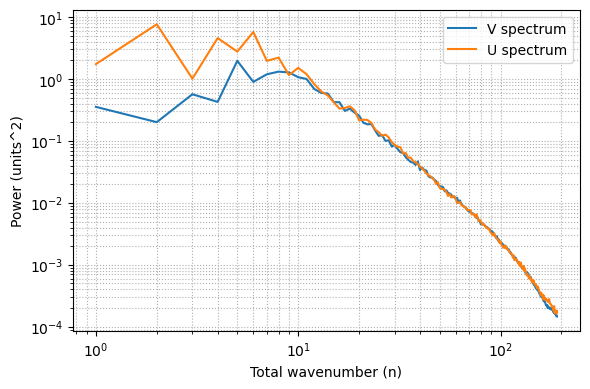

In [4]:
dir_in = PRODUCTION_NETCDF_DIR
init_time = '/2022-04-03T00Z/'
Fils = sorted(glob.glob(dir_in+init_time+'*.nc'))
DS = xr.open_mfdataset(Fils)
ds_v = DS['V'].sel(level=200,method='nearest').rename({'latitude':'lat', 'longitude':'lon'}).load().to_dataset(name='V')
ds_u = DS['U'].sel(level=200,method='nearest').rename({'latitude':'lat', 'longitude':'lon'}).load().to_dataset(name='U')


u_ds = ensure_ascending_lat(ds_v)
v_ds = ensure_ascending_lat(ds_u)

u_da = ds_u['U'].transpose("time", "lat", "lon").load()
v_da = ds_v['V'].transpose("time", "lat", "lon").load()

#Basic consistency checks
if u_da.dims != v_da.dims:
    raise ValueError("U and V arrays must share dims (time, lat, lon).")
if not np.allclose(u_da.lon, v_da.lon):
    raise ValueError("Longitude coordinates do not match.")
if not np.allclose(u_da.lat, v_da.lat):
    raise ValueError("Latitude coordinates do not match.")
if not np.all(u_da.time.values == v_da.time.values):
    raise ValueError("Time coordinates do not match.")

print("Input dims:", u_da.shape)


ops = SpectralOpsTH(
    nlat=u_da.sizes["lat"],
    nlon=u_da.sizes["lon"],
    grid="lobatto",
    device="cpu",
    eps_default=1e-12,
)

lat_lib, lon_lib = ops.library_latlon()
target_grid = xr.Dataset(
    dict(
        lat=(["lat"], lat_lib.cpu().numpy()),
        lon=(["lon"], lon_lib.cpu().numpy()),
    )
)

rg_u = xe.Regridder(
    u_da.to_dataset(name="u"),
    target_grid,
    method="bilinear",
    periodic=True,
    reuse_weights=False,
)
rg_v = xe.Regridder(
    v_da.to_dataset(name="v"),
    target_grid,
    method="bilinear",
    periodic=True,
    reuse_weights=False,
)

u_da = rg_u(u_da.to_dataset(name="u"))["u"]
v_da = rg_v(v_da.to_dataset(name="v"))["v"]

print("Regridded dims:", u_da.shape)

# Total-wavenumber spectra for U and V
# -------------------------------------------------------------------
# limit to first N times if you want

spec_ds_v = scalar_power_spectrum_xr(
    v_da,
    ops,
    sample_dims=("time","ensemble"),
    name="power",
    scale_to_variance=True
)
spec_ds_u = scalar_power_spectrum_xr(
    u_da,
    ops,
    sample_dims=("time","ensemble"),
    name="power",
    scale_to_variance=True
)

n_v = spec_ds_v["n"].values
P_v = spec_ds_v["power"].values

n_u = spec_ds_u["n"].values
P_u = spec_ds_u["power"].values

# Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n_v[1:], P_v[1:], label="V spectrum")  # skip n=0 mean
ax.loglog(n_u[1:], P_u[1:], label="U spectrum")
ax.set_xlabel("Total wavenumber (n)")
ax.set_ylabel("Power (units^2)")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()

/glade/derecho/scratch/schreck/tmp/ipykernel_77036/635120004.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  DS = xr.open_mfdataset(Fils)


Input dims: (100, 60, 192, 288)
Regridded dims: (100, 60, 192, 288)


Scalar spectrum:   0%|          | 0/375 [00:00<?, ?it/s]

Scalar spectrum:   0%|          | 0/375 [00:00<?, ?it/s]

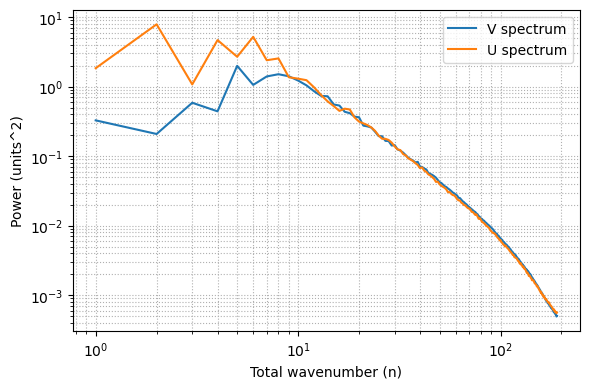

In [5]:
dir_in = SCHEDULER_DIR + '/netcdf_pressure_interp'
init_time = '/2022-04-03T00Z/'
Fils = sorted(glob.glob(dir_in+init_time+'*.nc'))
DS = xr.open_mfdataset(Fils)
ds_v = DS['V'].sel(level=500,method='nearest').isel(ensemble=slice(0,100)).rename({'latitude':'lat', 'longitude':'lon'}).load().to_dataset(name='V')
ds_u = DS['U'].sel(level=500,method='nearest').isel(ensemble=slice(0,100)).rename({'latitude':'lat', 'longitude':'lon'}).load().to_dataset(name='U')


u_ds = ensure_ascending_lat(ds_v)
v_ds = ensure_ascending_lat(ds_u)

u_da = ds_u['U'].transpose("ensemble", "time", "lat", "lon").load()
v_da = ds_v['V'].transpose("ensemble", "time", "lat", "lon").load()

#Basic consistency checks
if u_da.dims != v_da.dims:
    raise ValueError("U and V arrays must share dims (time, lat, lon).")
if not np.allclose(u_da.lon, v_da.lon):
    raise ValueError("Longitude coordinates do not match.")
if not np.allclose(u_da.lat, v_da.lat):
    raise ValueError("Latitude coordinates do not match.")
if not np.all(u_da.time.values == v_da.time.values):
    raise ValueError("Time coordinates do not match.")

print("Input dims:", u_da.shape)

ops = SpectralOpsTH(
    nlat=u_da.sizes["lat"],
    nlon=u_da.sizes["lon"],
    grid="lobatto",
    device="cpu",
    eps_default=1e-12,
)

lat_lib, lon_lib = ops.library_latlon()
target_grid = xr.Dataset(
    dict(
        lat=(["lat"], lat_lib.cpu().numpy()),
        lon=(["lon"], lon_lib.cpu().numpy()),
    )
)

rg_u = xe.Regridder(
    u_da.to_dataset(name="u"),
    target_grid,
    method="bilinear",
    periodic=True,
    reuse_weights=False,
)
rg_v = xe.Regridder(
    v_da.to_dataset(name="v"),
    target_grid,
    method="bilinear",
    periodic=True,
    reuse_weights=False,
)

u_da = rg_u(u_da.to_dataset(name="u"))["u"]
v_da = rg_v(v_da.to_dataset(name="v"))["v"]

print("Regridded dims:", u_da.shape)

# Total-wavenumber spectra for U and V
# -------------------------------------------------------------------
# limit to first N times if you want

spec_ds_v = scalar_power_spectrum_xr(
    v_da,
    ops,
    sample_dims=("time","ensemble"),
    name="power",
    scale_to_variance=True
)
spec_ds_u = scalar_power_spectrum_xr(
    u_da,
    ops,
    sample_dims=("time","ensemble"),
    name="power",
    scale_to_variance=True
)

n_v = spec_ds_v["n"].values
P_v = spec_ds_v["power"].values

n_u = spec_ds_u["n"].values
P_u = spec_ds_u["power"].values

# Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n_v[1:], P_v[1:], label="V spectrum")  # skip n=0 mean
ax.loglog(n_u[1:], P_u[1:], label="U spectrum")
ax.set_xlabel("Total wavenumber (n)")
ax.set_ylabel("Power (units^2)")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()

In [6]:
"""
Complete working code - structures data exactly like your working example
"""
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import torch
import math
from pathlib import Path
from glob import glob

EARTH_RADIUS = 6371000.0  # meters

def scalar_power_spectrum_xr(
    da: xr.DataArray,
    ops,
    *,
    sample_dims=("time",),
    remap_to_library_grid=True,
    batch_size=16,
    device=None,
    name="power",
    scale_to_variance=False,
    show_progress=True,
):
    """YOUR working function"""
    # lat/lon dim names
    lat_name = "lat" if "lat" in da.dims else "latitude"
    lon_name = "lon" if "lon" in da.dims else "longitude"
    if (lat_name, lon_name) != da.dims[-2:]:
        raise ValueError("Last two dims must be (lat, lon) or (latitude, longitude).")

    # 1) stack sample dims and move them to the front: (sample, lat, lon)
    sample_dims = tuple(d for d in sample_dims if d in da.dims)
    if len(sample_dims) == 0:
        da_sample = da.expand_dims(sample=[0]).transpose("sample", lat_name, lon_name)
    else:
        da_sample = (
            da
            .stack(sample=sample_dims)
            .transpose("sample", lat_name, lon_name)
        )

    # 2) remap to library grid if needed
    lat_lib_t, lon_lib_t = ops.library_latlon()
    lat_lib = np.asarray(lat_lib_t.cpu().numpy())
    lon_lib = np.asarray(lon_lib_t.cpu().numpy())

    same_lat = np.allclose(da_sample[lat_name].values, lat_lib, atol=1e-10)
    same_lon = np.allclose(da_sample[lon_name].values, lon_lib, atol=1e-10)

    if remap_to_library_grid and (not same_lat or not same_lon):
        da_in = da_sample.interp(
            {lat_name: lat_lib, lon_name: lon_lib},
            kwargs={"fill_value": "extrapolate"},
        )
    else:
        da_in = da_sample

    n_sample = da_in.sizes["sample"]
    dev = torch.device(device) if device is not None else ops.device
    dtype = torch.float64

    spec_sum = None
    count = 0

    steps = range(0, n_sample, batch_size)
    if show_progress:
        try:
            from tqdm.auto import tqdm
            steps = tqdm(
                steps,
                total=math.ceil(n_sample / batch_size),
                desc="Scalar spectrum",
                leave=False,
            )
        except Exception:
            pass

    # 3) loop over samples in batches
    for i0 in steps:
        i1 = min(n_sample, i0 + batch_size)

        # values.shape -> (B, nlat, nlon)
        blk = torch.from_numpy(
            da_in.isel(sample=slice(i0, i1)).values
        ).to(dtype=dtype, device=dev)

        for b in range(blk.shape[0]):
            f = blk[b]  # (nlat, nlon)
            spec_l = ops.scalar_power_spectrum(f)  # raw sum_m |f_lm|^2
            if spec_sum is None:
                spec_sum = torch.zeros_like(spec_l)
            spec_sum += spec_l
            count += 1

        del blk
        if dev.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

    if count == 0:
        raise ValueError("No samples found to average over.")

    # 4) average over samples
    spec_mean = (spec_sum / count).detach().to("cpu").numpy()

    # 5) optional scaling to variance units
    if scale_to_variance:
        spec_mean = spec_mean / (2.0 * np.pi)

    l_dim = spec_mean.shape[0]
    n = np.arange(l_dim, dtype=int)

    # isotropic length scale (km), n=0 undefined
    a = EARTH_RADIUS
    length_scale = np.empty_like(spec_mean, dtype=float)
    length_scale[0] = np.nan
    nn = n[1:].astype(float)
    length_scale[1:] = 2 * np.pi * a / np.sqrt(nn * (nn + 1.0))
    length_scale_km = length_scale / 1000.0

    ds = xr.Dataset(
        data_vars={name: (("n",), spec_mean)},
        coords={
            "n": n,
            "L_iso_km": (("n",), length_scale_km),
        },
    )
    return ds


def load_beta_experiment(pkl_path, u_idx=11, v_idx=12, lead_idx=-3):
    """
    Load experiment and structure EXACTLY like your working example.
    Returns DataArrays with dims (ensemble, lat, lon).
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    # predictions shape: (ensemble, channels, time, lat, lon)
    preds = data['predictions']
    n_ens, _, n_ch, n_time, n_lat, n_lon = preds.shape
    
    # Extract U and V at lead_idx: (ensemble, lat, lon)
    u_data = preds[:, 0, u_idx, lead_idx, :, :]
    v_data = preds[:, 0, v_idx, lead_idx, :, :]
    
    # Create coordinates
    lat_coords = np.linspace(90, -90, n_lat)
    lon_coords = np.linspace(0, 360, n_lon, endpoint=False)
    
    # Create DataArrays EXACTLY like your example
    u_da = xr.DataArray(
        u_data,
        dims=['ensemble', 'lat', 'lon'],
        coords={
            'ensemble': np.arange(n_ens),
            'lat': lat_coords,
            'lon': lon_coords
        },
        name='U'
    )
    
    v_da = xr.DataArray(
        v_data,
        dims=['ensemble', 'lat', 'lon'],
        coords={
            'ensemble': np.arange(n_ens),
            'lat': lat_coords,
            'lon': lon_coords
        },
        name='V'
    )
    
    # Ensure ascending latitude
    if u_da.lat[0] > u_da.lat[-1]:
        u_da = u_da.isel(lat=slice(None, None, -1))
        v_da = v_da.isel(lat=slice(None, None, -1))
    
    return {
        'u': u_da,
        'v': v_da,
        'betas': data.get('betas', [1.0, 1.0, 1.0]),
        'name': data['exp_name']
    }


# ============================================================================
# MAIN
# ============================================================================

# Setup
data_dir = '/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/beta_data'
output_dir = Path('/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/beta_data/spectral_analysis')
output_dir.mkdir(exist_ok=True, parents=True)

# Find experiments
all_pkls = glob(f"{data_dir}/*.pkl")

baseline = None
beta1_exps = []
beta2_exps = []
beta3_exps = []

for pkl in all_pkls:
    name = Path(pkl).stem
    if 'baseline_reference' in name or name == 'baseline_saved':
        baseline = pkl
    elif 'beta1_' in name:
        beta1_exps.append(pkl)
    elif 'beta2_' in name:
        beta2_exps.append(pkl)
    elif 'beta3_' in name:
        beta3_exps.append(pkl)

print(f"Found: baseline={baseline is not None}, beta1={len(beta1_exps)}, beta2={len(beta2_exps)}, beta3={len(beta3_exps)}")

# Load baseline
print("\nLoading baseline...")
baseline_data = load_beta_experiment(baseline)
print(f"Baseline U shape: {baseline_data['u'].shape}")
print(f"Baseline U dims: {baseline_data['u'].dims}")

# Setup spectral ops
nlat = baseline_data['u'].sizes['lat']
nlon = baseline_data['u'].sizes['lon']
print(f"\nGrid: {nlat} x {nlon}")
ops = SpectralOpsTH(nlat=nlat, nlon=nlon, grid="lobatto", device="cpu", eps_default=1e-12)

# Compute baseline spectra
print("\nComputing baseline spectra...")
spec_u = scalar_power_spectrum_xr(
    baseline_data['u'], ops,
    sample_dims=("ensemble",),
    remap_to_library_grid=True,
    batch_size=16,
    name="power",
    scale_to_variance=True,
    show_progress=True
)
spec_v = scalar_power_spectrum_xr(
    baseline_data['v'], ops,
    sample_dims=("ensemble",),
    remap_to_library_grid=True,
    batch_size=16,
    name="power",
    scale_to_variance=True,
    show_progress=True
)

# KE = 0.5 * (u^2 + v^2)
baseline_ke = 0.5 * (spec_u['power'].values + spec_v['power'].values)
n = spec_u['n'].values

print(f"Baseline KE spectrum shape: {baseline_ke.shape}")

# # Create figure: 4 panels
# fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=150)

# # Panel 1: Baseline
# ax = axes[0]
# ax.loglog(n[1:], baseline_ke[1:], 'k-', linewidth=3, label='Mean')

# # Reference slopes
# n_ref = np.array([5, 30])
# k3 = baseline_ke[10] * (n_ref / 10)**(-3)
# k53 = baseline_ke[10] * (n_ref / 10)**(-5/3)
# ax.loglog(n_ref, k3, 'r--', alpha=0.5, linewidth=2, label='k⁻³')
# ax.loglog(n_ref, k53, 'b--', alpha=0.5, linewidth=2, label='k⁻⁵/³')

# ax.set_xlabel('Wavenumber (n)', fontsize=12, )
# ax.set_ylabel('KE Power (m²/s²)', fontsize=12, )
# ax.set_title('Baseline (β=[1,1,1])', fontsize=13, )
# ax.grid(True, which='both', alpha=0.3, linestyle=':')
# ax.legend(fontsize=9)
# ax.set_xlim(1, 100)

# # Panel 2-4: Beta experiments
# for panel_idx, (beta_exps, layer_name, scale_range) in enumerate([
#     (beta1_exps, 'β₁ (Planetary)', (1, 10)),
#     (beta2_exps, 'β₂ (Synoptic)', (10, 30)),
#     (beta3_exps, 'β₃ (Mesoscale)', (30, 80))
# ]):
#     ax = axes[panel_idx + 1]
#     colors = plt.cm.RdBu_r(np.linspace(0, 1, len(beta_exps)))
    
#     for pkl, color in zip(sorted(beta_exps), colors):
#         print(f"\nProcessing {Path(pkl).stem}...")
#         exp_data = load_beta_experiment(pkl)
        
#         # Compute spectra
#         spec_u = scalar_power_spectrum_xr(
#             exp_data['u'], ops,
#             sample_dims=("ensemble",),
#             remap_to_library_grid=True,
#             batch_size=16,
#             name="power",
#             scale_to_variance=True,
#             show_progress=False
#         )
#         spec_v = scalar_power_spectrum_xr(
#             exp_data['v'], ops,
#             sample_dims=("ensemble",),
#             remap_to_library_grid=True,
#             batch_size=16,
#             name="power",
#             scale_to_variance=True,
#             show_progress=False
#         )
        
#         ke = 0.5 * (spec_u['power'].values + spec_v['power'].values)
        
#         beta_val = exp_data['betas'][panel_idx]
#         ax.loglog(n[1:], ke[1:], color=color, linewidth=2.5,
#                  label=f"β={beta_val:.1f}", alpha=0.8)
    
#     ax.loglog(n_ref, k3, 'k--', alpha=0.3, linewidth=1.5)
#     ax.loglog(n_ref, k53, 'k:', alpha=0.3, linewidth=1.5)
#     ax.set_xlabel('Wavenumber (n)', fontsize=12, )
#     ax.set_title(layer_name, fontsize=13, )
#     ax.grid(True, which='both', alpha=0.3, linestyle=':')
#     ax.legend(fontsize=8, loc='best')
#     ax.set_xlim(1, 100)
#     ax.axvspan(*scale_range, alpha=0.1, color='gray')

# plt.suptitle('KE Spectra: Baseline vs β Parameter Variations | T+108h',
#             fontsize=15, , y=1.02)
# plt.tight_layout()

# # output_path = output_dir / 'beta_comparison_4panel.png'
# # plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
# # print(f"\n✓ Saved to {output_path}")
# plt.show()

Found: baseline=True, beta1=6, beta2=6, beta3=6

Loading baseline...
Baseline U shape: (20, 192, 288)
Baseline U dims: ('ensemble', 'lat', 'lon')

Grid: 192 x 288

Computing baseline spectra...


Scalar spectrum:   0%|          | 0/2 [00:00<?, ?it/s]

Scalar spectrum:   0%|          | 0/2 [00:00<?, ?it/s]

Baseline KE spectrum shape: (191,)


In [7]:
# Cache for computed spectra to avoid recomputation
if 'spectra_cache' not in globals():
    spectra_cache = {}

def get_or_compute_ke(pkl, exp_data, panel_idx, ops, n):
    """Get KE from cache or compute if not cached"""
    cache_key = (pkl, panel_idx)
    
    if cache_key in spectra_cache:
        return spectra_cache[cache_key]
    
    spec_u = scalar_power_spectrum_xr(
        exp_data['u'], ops,
        sample_dims=("ensemble",),
        remap_to_library_grid=True,
        batch_size=16,
        name="power",
        scale_to_variance=True,
        show_progress=False
    )
    spec_v = scalar_power_spectrum_xr(
        exp_data['v'], ops,
        sample_dims=("ensemble",),
        remap_to_library_grid=True,
        batch_size=16,
        name="power",
        scale_to_variance=True,
        show_progress=False
    )
    
    ke = 0.5 * (spec_u['power'].values + spec_v['power'].values)
    spectra_cache[cache_key] = ke
    
    return ke

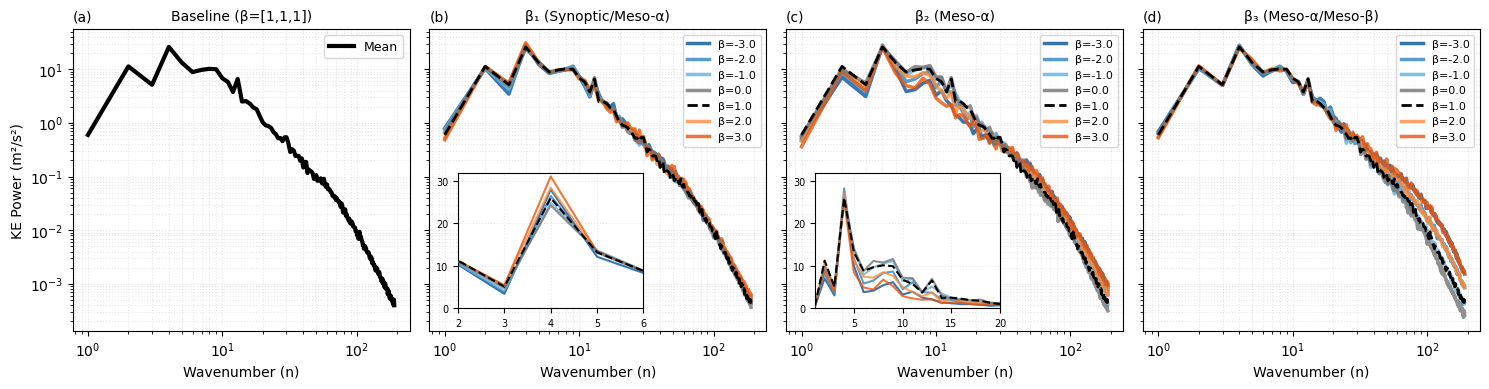

In [8]:
# Create figure: 4 panels
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
# Panel 1: Baseline
ax = axes[0]
ax.text(0.0, 1.065, '(a)', transform=ax.transAxes, fontsize=10,
        va='top', ha='left')
ax.loglog(n[1:], baseline_ke[1:], 'k-', linewidth=3, label='Mean')
ax.set_xlabel('Wavenumber (n)', fontsize=10)
ax.set_ylabel('KE Power (m²/s²)', fontsize=10)
ax.set_title('Baseline (β=[1,1,1])', fontsize=10)
ax.grid(True, which='both', alpha=0.3, linestyle=':')
ax.legend(fontsize=9)
# Panel 2-4: Beta experiments
for panel_idx, (beta_exps, layer_name, scale_range) in enumerate([
    (beta1_exps, 'β₁ (Synoptic/Meso-α)', (1, 10)),
    (beta2_exps, 'β₂ (Meso-α)', (10, 30)),
    (beta3_exps, 'β₃ (Meso-α/Meso-β)', (30, 80))
]):
    ax = axes[panel_idx + 1]
    
    # Add panel label
    panel_label = ['(b)', '(c)', '(d)'][panel_idx]
    ax.text(0.0, 1.065, panel_label, transform=ax.transAxes, fontsize=10, va='top', ha='left')
    
    # Collect experiments with their beta values for sorting
    exp_data_list = []
    
    for pkl in beta_exps:
        exp_data = load_beta_experiment(pkl)
        beta_val = exp_data['betas'][panel_idx]
        exp_data_list.append((beta_val, pkl, exp_data))
    
    # Sort by beta value (keeps legend ordered)
    exp_data_list.sort(key=lambda x: x[0])
    
    dark_colors = [
        '#08519c',  # dark blue (β=-3)
        '#3182bd',  # medium blue (β=-2)  
        '#6baed6',  # light blue (β=-1)
        '#737373',  # gray (β=0)
        '#fd8d3c',  # orange (β=1)
        '#e6550d',  # dark orange (β=2)
        '#a63603',  # dark red (β=3)
    ]
    
    # Store KE values for inset reuse
    ke_values = []
    
    # Collect handles and labels for proper ordering
    handles = []
    labels = []
    
    for (beta_val, pkl, exp_data), color in zip(exp_data_list, dark_colors):    
        # Get or compute KE (uses cache)
        ke = get_or_compute_ke(pkl, exp_data, panel_idx, ops, n)
        ke_values.append((beta_val, ke, color))
        
        # Plot in order but beta=0 gets higher zorder
        zorder = 10 if abs(beta_val) < 0.01 else 2
        if beta_val == 0:
            zorder = 50
        
        line, = ax.loglog(n[1:], ke[1:], color=color, linewidth=2.5,
                         alpha=0.8, zorder=zorder)
        handles.append(line)
        labels.append(f"β={beta_val:.1f}")
    
    # Add β=1 reference line and insert into correct position
    line_baseline, = ax.loglog(n[1:], baseline_ke[1:], 'k--', linewidth=2, 
                                alpha=1.0, zorder=100)
    
    # Insert β=1 after β=0 in the legend (position 4: after -3,-2,-1,0)
    handles.insert(4, line_baseline)
    labels.insert(4, 'β=1.0')
    
    ax.set_xlabel('Wavenumber (n)', fontsize=10)
    ax.set_title(layer_name, fontsize=10)
    ax.grid(True, which='both', alpha=0.3, linestyle=':')
    ax.legend(handles, labels, fontsize=8, loc='best')
    # ax.axvspan(*scale_range, alpha=0.1, color='k')
    
    # Add insets for the two middle panels (lower left)
    if panel_idx in [0, 1]:
        axins = ax.inset_axes([0.085, 0.075, 0.55, 0.45])
        
        # Reuse computed KE values
        for beta_val, ke, color in ke_values:
            zorder = 10 if abs(beta_val) < 0.01 else 2
            axins.plot(n[1:], ke[1:], color=color, linewidth=1.5, 
                        alpha=0.8, zorder=zorder)
        
        axins.plot(n[1:], baseline_ke[1:], 'k--', linewidth=1.5, 
                    alpha=1.0, zorder=100)
        
        if panel_idx == 0:  # β₁ - focus on n=4 region
            axins.set_xlim(2, 6)
        else:  # β₂
            axins.set_xlim(1, 20)
            
        axins.set_ylim(0, 32)
        
        axins.grid(True, which='both', alpha=0.3, linestyle=':')
        axins.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

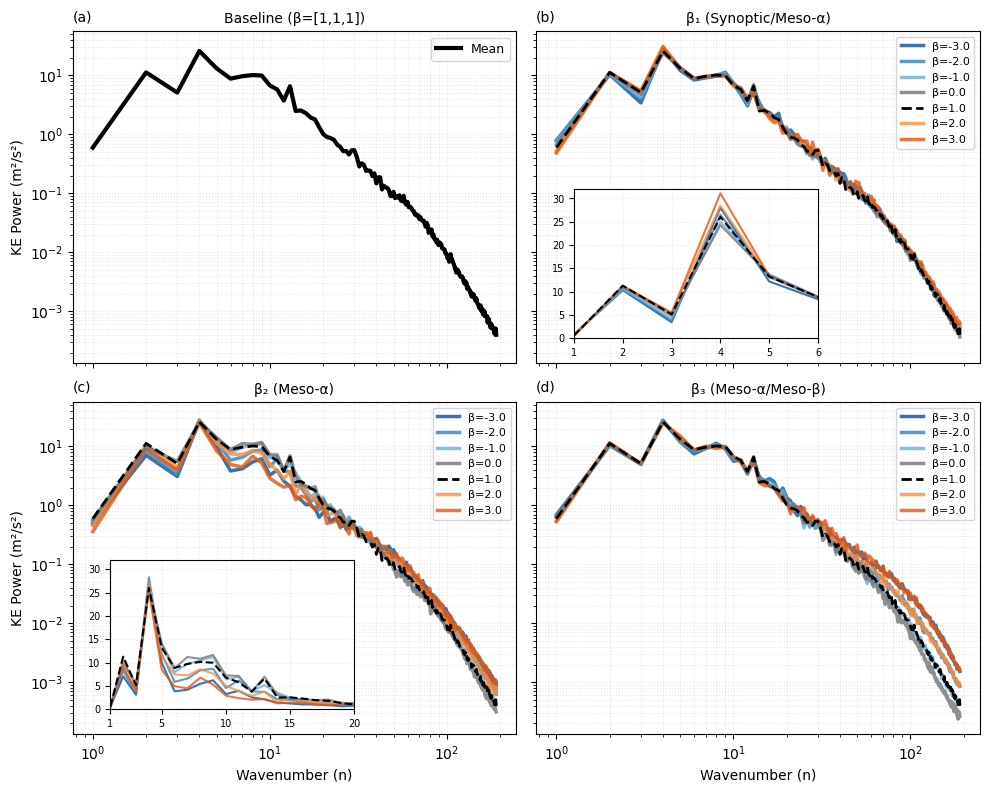

In [10]:
# Create figure: 2x2 panels
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

# Panel 1: Baseline
ax = axes[0]
ax.text(0.0, 1.065, '(a)', transform=ax.transAxes, fontsize=10,
        va='top', ha='left')
ax.loglog(n[1:], baseline_ke[1:], 'k-', linewidth=3, label='Mean')
ax.set_ylabel('KE Power (m²/s²)', fontsize=10)
ax.set_title('Baseline (β=[1,1,1])', fontsize=10)
ax.grid(True, which='both', alpha=0.3, linestyle=':')
ax.legend(fontsize=9)

# Panel 2-4: Beta experiments
for panel_idx, (beta_exps, layer_name, scale_range) in enumerate([
    (beta1_exps, 'β₁ (Synoptic/Meso-α)', (1, 10)),
    (beta2_exps, 'β₂ (Meso-α)', (10, 30)),
    (beta3_exps, 'β₃ (Meso-α/Meso-β)', (30, 80))
]):
    ax = axes[panel_idx + 1]
    
    # Add panel label
    panel_label = ['(b)', '(c)', '(d)'][panel_idx]
    ax.text(0.0, 1.065, panel_label, transform=ax.transAxes, fontsize=10, va='top', ha='left')
    
    # Collect experiments with their beta values for sorting
    exp_data_list = []
    
    for pkl in beta_exps:
        exp_data = load_beta_experiment(pkl)
        beta_val = exp_data['betas'][panel_idx]
        exp_data_list.append((beta_val, pkl, exp_data))
    
    # Sort by beta value (keeps legend ordered)
    exp_data_list.sort(key=lambda x: x[0])
    
    dark_colors = [
        '#08519c',  # dark blue (β=-3)
        '#3182bd',  # medium blue (β=-2)  
        '#6baed6',  # light blue (β=-1)
        '#737373',  # gray (β=0)
        '#fd8d3c',  # orange (β=1)
        '#e6550d',  # dark orange (β=2)
        '#a63603',  # dark red (β=3)
    ]
    
    # Store KE values for inset reuse
    ke_values = []
    
    # Collect handles and labels for proper ordering
    handles = []
    labels = []
    
    for (beta_val, pkl, exp_data), color in zip(exp_data_list, dark_colors):    
        # Get or compute KE (uses cache)
        ke = get_or_compute_ke(pkl, exp_data, panel_idx, ops, n)
        ke_values.append((beta_val, ke, color))
        
        # Plot in order but beta=0 gets higher zorder
        zorder = 10 if abs(beta_val) < 0.01 else 2
        if beta_val == 0:
            zorder = 50
        
        line, = ax.loglog(n[1:], ke[1:], color=color, linewidth=2.5,
                         alpha=0.8, zorder=zorder)
        handles.append(line)
        labels.append(f"β={beta_val:.1f}")
    
    # Add β=1 reference line and insert into correct position
    line_baseline, = ax.loglog(n[1:], baseline_ke[1:], 'k--', linewidth=2, 
                                alpha=1.0, zorder=100)
    
    # Insert β=1 after β=0 in the legend (position 4: after -3,-2,-1,0)
    handles.insert(4, line_baseline)
    labels.insert(4, 'β=1.0')
    
    ax.set_title(layer_name, fontsize=10)
    ax.grid(True, which='both', alpha=0.3, linestyle=':')
    ax.legend(handles, labels, fontsize=8, loc='best')
    
    # Add insets for the two middle panels (lower left)
    if panel_idx in [0, 1]:
        axins = ax.inset_axes([0.085, 0.075, 0.55, 0.45])
        
        # Reuse computed KE values
        for beta_val, ke, color in ke_values:
            zorder = 10 if abs(beta_val) < 0.01 else 2
            axins.plot(n[1:], ke[1:], color=color, linewidth=1.5, 
                        alpha=0.8, zorder=zorder)
        
        axins.plot(n[1:], baseline_ke[1:], 'k--', linewidth=1.5, 
                    alpha=1.0, zorder=100)
        
        if panel_idx == 0:  # β₁ - focus on n=4 region
            axins.set_xlim(1, 6)
            axins.set_xticks([1, 2, 3, 4, 5, 6])
        else:  # β₂
            axins.set_xlim(1, 20)
            axins.set_xticks([1, 5, 10, 15, 20])
            
        axins.set_ylim(0, 32)
        
        axins.grid(True, which='both', alpha=0.3, linestyle=':')
        axins.tick_params(labelsize=7)

# Add labels for left column only (indices 0 and 2)
axes[2].set_ylabel('KE Power (m²/s²)', fontsize=10)

# Add labels for bottom row only (indices 2 and 3)
axes[2].set_xlabel('Wavenumber (n)', fontsize=10)
axes[3].set_xlabel('Wavenumber (n)', fontsize=10)

plt.tight_layout()
plt.savefig("ke_spectra.png", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()